In [1]:
import os
import json
from google.colab import userdata

os.makedirs('/root/.kaggle', exist_ok=True)

# Kaggle credentials are loaded from Colab Secrets (key icon in the left sidebar).
# To run this notebook, add your own KAGGLE_USERNAME and KAGGLE_KEY there.
creds = {
    'username': userdata.get('KAGGLE_USERNAME'),
    'key': userdata.get('KAGGLE_KEY'),
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle credentials configured.')

Kaggle credentials configured.


In [ ]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
!unzip -q cifake-real-and-ai-generated-synthetic-images.zip -d cifake_data
print('Dataset downloaded and extracted.')

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:00<00:00, 118MB/s] 

Dataset downloaded and extracted.


In [ ]:
# -------------------------------------------------------
# IMPORTS
# -------------------------------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from pathlib import Path
from tqdm import tqdm
import random

# TensorFlow / Keras (kept getting an error about not being able to import keras, so I switched to tensorflow.keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Scikit-learn metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f'TensorFlow version: {tf.__version__}')
# Make sure using GPU (learned the hard way)
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
# -------------------------------------------------------
# DATASET PATHS
# -------------------------------------------------------
# CIFAKE folder structure: (from kaggle)
#   cifake_data/
#     train/
#       REAL/   (images)
#       FAKE/   (images)
#     test/
#       REAL/
#       FAKE/
# This was taken from kaggle directly.

DATA_DIR = Path('cifake_data')
TRAIN_DIR  = DATA_DIR / 'train'
TEST_DIR   = DATA_DIR / 'test'
IMG_SIZE   = (32, 32)
BATCH_SIZE = 64
SEED       = 42

# Confirm folder structure
for split in ['train', 'test']:
    for label in ['REAL', 'FAKE']: # Loop through each folder and count images
        count = len(list((DATA_DIR / split / label).glob('*.jpg'))) # Count .jpg files in each folder
        print(f'{split}/{label}: {count} images')

train/REAL: 50000 images
train/FAKE: 50000 images
test/REAL: 10000 images
test/FAKE: 10000 images


In [ ]:
# Load images from a directory split (train or test) into numpy arrays
# Each split has two subfolders: REAL and FAKE
# We assign label 0 to REAL and 1 to FAKE based on enumerate order
def load_images_from_split(split_directory, max_per_class=None):
    """Load images as uint8 numpy arrays from a REAL/FAKE folder pair."""
    images, labels = [], []

    for label_index, label_name in enumerate(['REAL', 'FAKE']):
        folder = split_directory / label_name

        # glob finds all .jpg files in the folder and sorts them for consistency
        paths = sorted(folder.glob('*.jpg'))

        # tqdm wraps the loop to show a progress bar while loading
        for path in tqdm(paths, desc=f'Loading {split_directory.name}/{label_name}'):
            image = cv2.imread(str(path))

            # OpenCV loads images as BGR by default, convert to RGB
            # so colors display correctly in matplotlib
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            images.append(image)
            labels.append(label_index)  # 0=REAL, 1=FAKE

    # We must convert to numpy arrays for pretty much any OpenCV or matplotlib stuff to work.
    return np.array(images), np.array(labels)

# Load full 60,000 images, Dr. Jiang if you need set this to 500 if you don't have a colab gpu available.
sample_images, sample_labels = load_images_from_split(TRAIN_DIR, max_per_class=60000)
print(f'Sample shape: {sample_images.shape}, Labels: {sample_labels.shape}')

Loading train/FAKE: 100%|██████████| 50000/50000 [00:02<00:00, 17506.43it/s]


Sample shape: (100000, 32, 32, 3), Labels: (100000,)


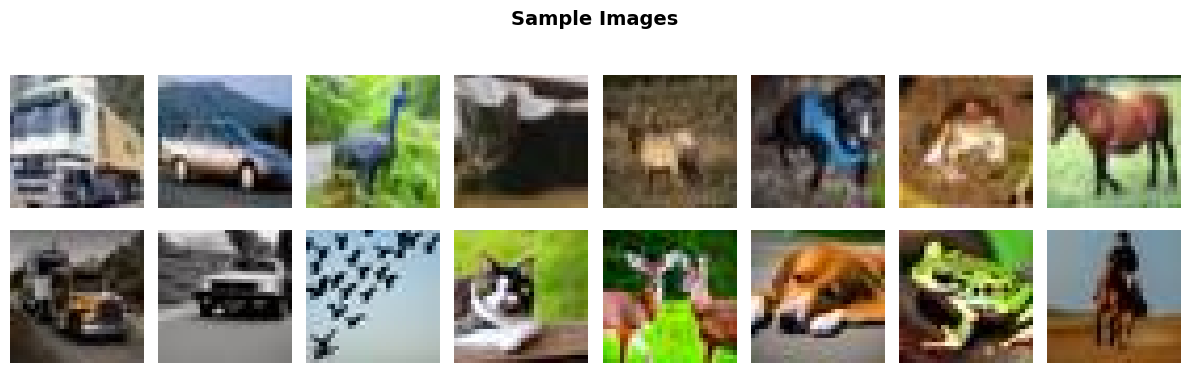

In [ ]:
# Visualize a side by side grid of REAL vs FAKE images
# to get a feel for what the dataset looks like before any processing
def show_sample_grid(images, labels, n=8, title='Sample Images'):

    # Claude helped me here
    real_indices = np.where(labels == 0)[0][:n]
    fake_indices = np.where(labels == 1)[0][:n]

    # Make two rows, fake and real.
    figure, axes = plt.subplots(2, n, figsize=(n * 1.5, 4))
    figure.suptitle(title, fontsize=14, fontweight='bold')

    # zip pairs up real and fake indices so we can fill both rows at once
    for column, (real, fake) in enumerate(zip(real_indices, fake_indices)):

        axes[0, column].imshow(images[real])
        axes[0, column].axis('off')  # hide axis ticks and labels

        # only add the row label on the first column to avoid repetition
        if column == 0:
            axes[0, column].set_ylabel('REAL', fontsize=10, rotation=0, labelpad=35)

        axes[1, column].imshow(images[fake])
        axes[1, column].axis('off')
        if column == 0:
            axes[1, column].set_ylabel('FAKE', fontsize=10, rotation=0, labelpad=35)

    plt.tight_layout()
    plt.show()

show_sample_grid(sample_images, sample_labels)

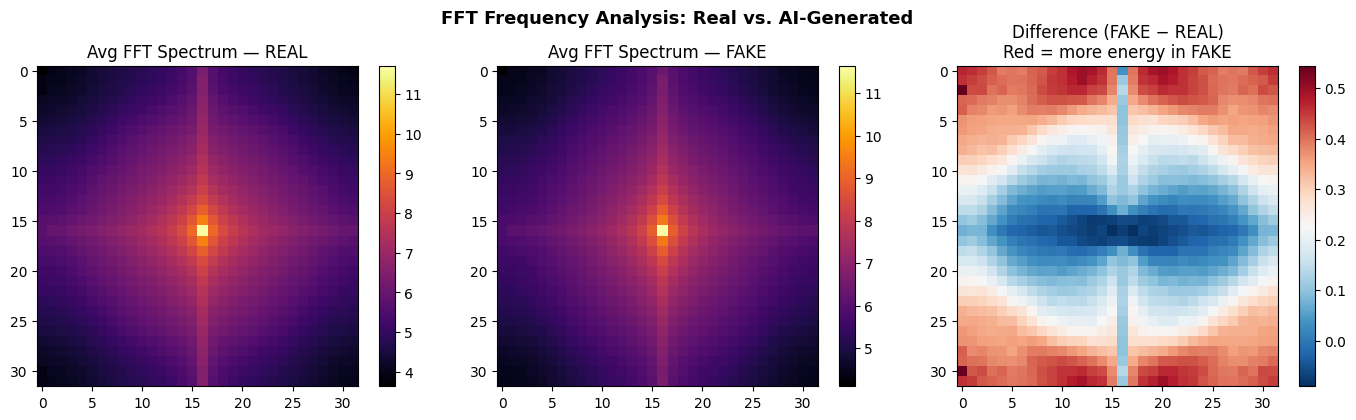

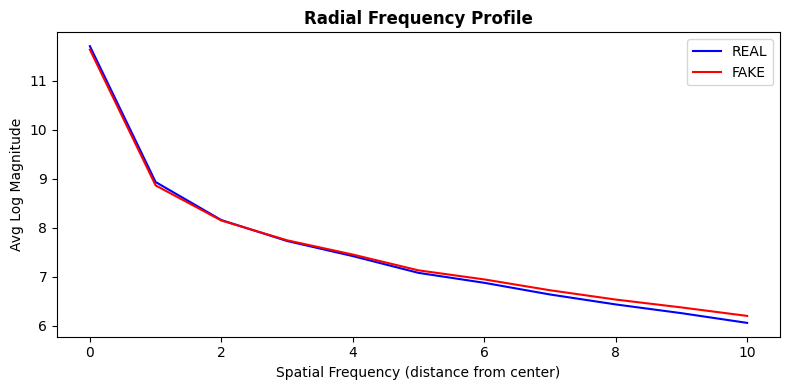

In [ ]:
# FFT converts images from spatial domain (pixel values) to frequency domain
# same fourier transform from class, just applied to 2D images

def compute_avg_fft(images):
    """Compute average 2D FFT magnitude spectrum (log scale) for a set of images."""
    spectra = []
    for image in images:
        # grayscale because we only care about brightness, not color
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32)

        # fft2 converts the image from pixel values to frequency components
        fft = np.fft.fft2(gray)

        # fftshift moves low frequencies to the center so its easier to look at
        fft_shifted = np.fft.fftshift(fft)

        # log1p compresses the values so the plot doesnt just look like one big spike
        magnitude = np.log1p(np.abs(fft_shifted))
        spectra.append(magnitude)

    # average across all images so we get the class signature, not just one image
    # axis=0 means average across images not pixels
    return np.mean(spectra, axis=0)

# split into real and fake for comparison
real_images = sample_images[sample_labels == 0]
fake_images = sample_images[sample_labels == 1]

# compute average spectrum for each class
avg_fft_real = compute_avg_fft(real_images)
avg_fft_fake = compute_avg_fft(fake_images)

# subtract real from fake, positive means fake has more energy at that frequency
fft_difference = avg_fft_fake - avg_fft_real

figure, axes = plt.subplots(1, 3, figsize=(14, 4))
figure.suptitle('FFT Frequency Analysis: Real vs. AI-Generated', fontsize=13, fontweight='bold')

# inferno colormap, brighter means more energy
image0 = axes[0].imshow(avg_fft_real, cmap='inferno')
axes[0].set_title('Avg FFT Spectrum — REAL')
plt.colorbar(image0, ax=axes[0])

image1 = axes[1].imshow(avg_fft_fake, cmap='inferno')
axes[1].set_title('Avg FFT Spectrum — FAKE')
plt.colorbar(image1, ax=axes[1])

# red means fake has more energy there, blue means real does
image2 = axes[2].imshow(fft_difference, cmap='RdBu_r')
axes[2].set_title('Difference (FAKE − REAL)\nRed = more energy in FAKE')
plt.colorbar(image2, ax=axes[2])

plt.tight_layout()
plt.show()

# collapses the 2D spectrum into a 1D line by averaging pixels at the same
# distance from center, gives us energy vs spatial frequency as a simple chart
def radial_profile(spectrum):
    """Collapse a 2D spectrum to a 1D radial average (energy vs. distance from center)."""

    # find center of the spectrum
    center_y, center_x = np.array(spectrum.shape) // 2

    # get y and x coordinates for every pixel
    y_coords, x_coords = np.indices(spectrum.shape)

    # distance from center using pythagorean theorem, cast to int for binning
    radius = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2).astype(int)

    # bincount sums values at each radius, dividing by count gives the average
    profile = np.bincount(radius.ravel(), weights=spectrum.ravel()) / np.bincount(radius.ravel())
    return profile

radial_real = radial_profile(avg_fft_real)
radial_fake = radial_profile(avg_fft_fake)

# only plot first half, second half is a mirror due to FFT symmetry
figure, ax = plt.subplots(figsize=(8, 4))
ax.plot(radial_real[:len(radial_real)//2], label='REAL', color='blue')
ax.plot(radial_fake[:len(radial_fake)//2], label='FAKE', color='red')
ax.set_title('Radial Frequency Profile', fontweight='bold')
ax.set_xlabel('Spatial Frequency (distance from center)')
ax.set_ylabel('Avg Log Magnitude')
ax.legend()
plt.tight_layout()
plt.show()

## FFT results:
The average FFT spectrums look identical, so their overall frequencies very closely match. The Radial profile shows the only noticeable difference across all 60,000 images, where the mid-high frequencies FAKE line is consistently above the REAL, which appears to suggest that AI images, for this dataset, have slighty finer details.

/tmp/ipykernel_6388/502232172.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([real_edge_densities, fake_edge_densities], labels=['REAL', 'FAKE'],


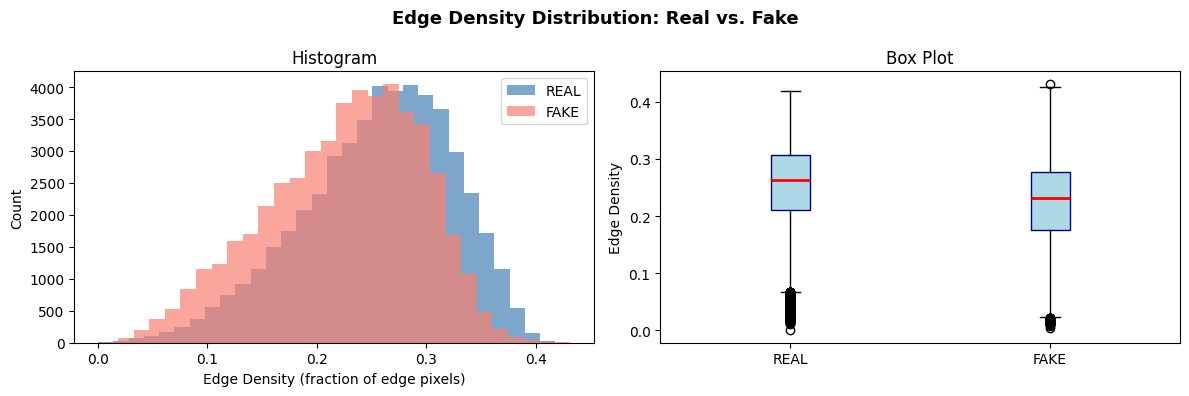

Mean edge density — REAL: 0.2553 | FAKE: 0.2242


In [ ]:
# For this I want to see if there is a difference in how many edges both have, and whether AI images have more or less. I will use Canny because that's all I remember from class beyond the filters we had applied ourselves.

real_edge_densities = []
for image in real_images:
    # convert to grayscale since canny works on brightness not color
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # I applied with the basic 50-150 range.
    edges = cv2.Canny(gray, 50, 150)

    # edges > 0 gives a boolean mask of edge pixels
    # dividing by edges.size gives the fraction of pixels that are edges
    real_edge_densities.append(np.sum(edges > 0) / edges.size)

real_edge_densities = np.array(real_edge_densities)

# same process for fake images
fake_edge_densities = []
for image in fake_images:
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    fake_edge_densities.append(np.sum(edges > 0) / edges.size)

fake_edge_densities = np.array(fake_edge_densities)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
figure.suptitle('Edge Density Distribution: Real vs. Fake', fontsize=13, fontweight='bold')

# histogram shows the full distribution of edge densities across all images
# alpha=0.7 makes both histograms slightly transparent so they dont block each other
axes[0].hist(real_edge_densities, bins=30, color='steelblue', alpha=0.7, label='REAL')
axes[0].hist(fake_edge_densities, bins=30, color='salmon', alpha=0.7, label='FAKE')
axes[0].set_xlabel('Edge Density (fraction of edge pixels)')
axes[0].set_ylabel('Count')
axes[0].set_title('Histogram')
axes[0].legend()

# box plot shows median, spread, and outliers more clearly than the histogram
# patch_artist=True fills the boxes with color instead of leaving them empty
axes[1].boxplot([real_edge_densities, fake_edge_densities], labels=['REAL', 'FAKE'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Edge Density')
axes[1].set_title('Box Plot')

plt.tight_layout()
plt.show()

# print the mean for each class to get a concrete number for the report
print(f'Mean edge density — REAL: {real_edge_densities.mean():.4f} | FAKE: {fake_edge_densities.mean():.4f}')

## Edge percentage analysis.
The mean edge density per REAL images was on average much higher than FAKE, showing that REAL images have a significant amount more of edges than FAKE. The overlap between the classes is not enough to have it be the sole determinator for the model, but it will be useful.

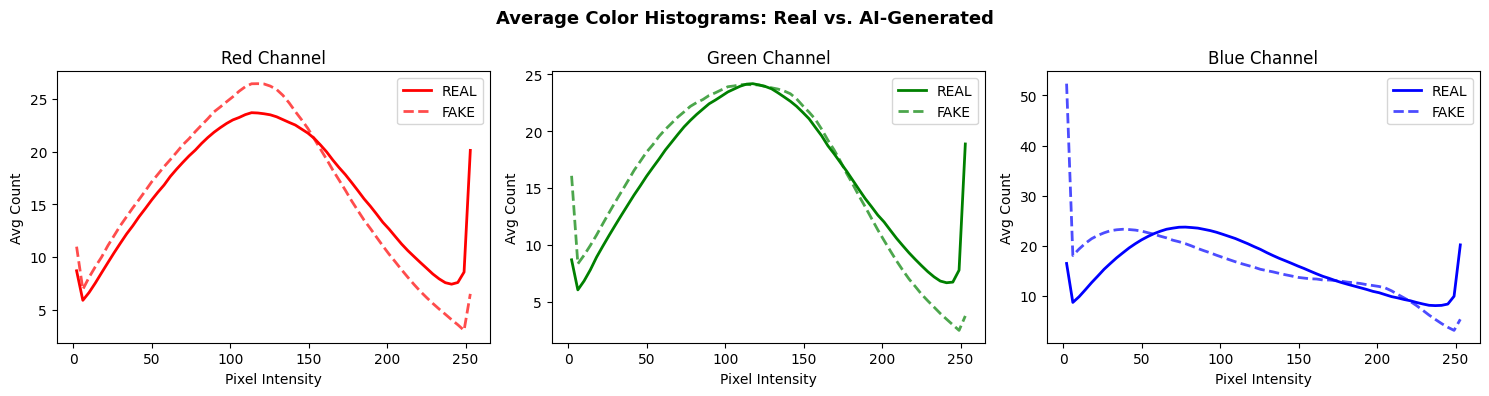

In [ ]:
# next we check the color channels red, green, blue, following RGB format.

# compute average histogram for each RGB channel across all real images
real_hist = np.zeros((3, 64))
for image in real_images:
    for channel in range(3):
        # np.histogram counts how many pixels fall into each brightness bin
        # range=(0, 255) covers all possible pixel values
        hist, _ = np.histogram(image[:, :, channel], bins=64, range=(0, 255))
        real_hist[channel] += hist

# divide by number of images to get the average
real_hist = real_hist / len(real_images)

# same for fake images
fake_hist = np.zeros((3, 64))
for image in fake_images:
    for channel in range(3):
        hist, _ = np.histogram(image[:, :, channel], bins=64, range=(0, 255))
        fake_hist[channel] += hist

fake_hist = fake_hist / len(fake_images)

# bin centers give us the x axis pixel intensity values
# linspace creates 65 evenly spaced edges, averaging adjacent edges gives 64 centers
bin_edges = np.linspace(0, 255, 65)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

channels = ['Red', 'Green', 'Blue']
colors   = ['red', 'green', 'blue']

figure, axes = plt.subplots(1, 3, figsize=(15, 4))
figure.suptitle('Average Color Histograms: Real vs. AI-Generated', fontsize=13, fontweight='bold')

# plot each channel separately, solid line for real, dashed for fake
for index, (channel, color) in enumerate(zip(channels, colors)):
    axes[index].plot(bin_centers, real_hist[index], color=color, label='REAL', linewidth=2)
    axes[index].plot(bin_centers, fake_hist[index], color=color, linestyle='--', label='FAKE',
                     linewidth=2, alpha=0.7)
    axes[index].set_title(f'{channel} Channel')
    axes[index].set_xlabel('Pixel Intensity')
    axes[index].set_ylabel('Avg Count')
    axes[index].legend()

plt.tight_layout()
plt.show()

## Color analysis
It looks like consistently AI generated images have much more low frequency blow tones, meaning AI images contain significantly more dark blue pixels than real images, it'd be cool to see if the model picks this up. The other colors match quite closely, as well as the higher frequencies for blue, with real images having much higher red and green in the exetreme range (255).

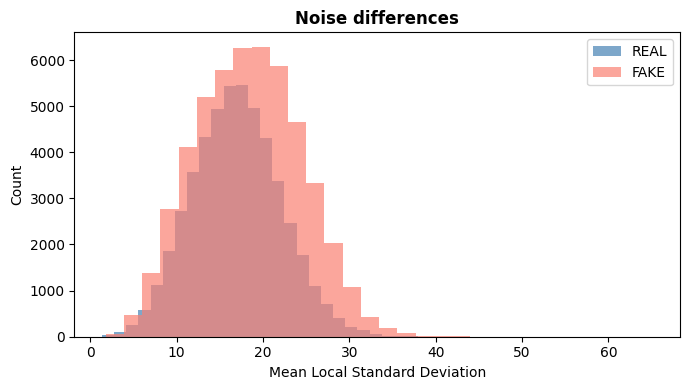

Mean local std — REAL: 16.9413 | FAKE: 18.3829


In [ ]:
# measure local noisiness of each image using a sliding 3x3 window
# for each window position we measure how much neighboring pixels vary from each other
# the mean local standard deviation gives us one noisiness score per image
# plotted on the graph

# averaging kernel, dividing by 9 (3x3) gives the mean of each 3x3 neighborhood
kernel = np.ones((3, 3), np.float32) / 9

real_noise = []
for image in real_images:
    # grayscale because we only care about brightness variation not color
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32)

    # slide the kernel across the image to get the local mean at every pixel
    local_mean = cv2.filter2D(gray, -1, kernel)

    # do the same on the squared pixel values which is needed for variance formula
    local_mean_squared = cv2.filter2D(gray**2, -1, kernel)

    # variance formula: E[X^2] - E[X]^2
    # clip to 0 to remove tiny negative values from floating point rounding
    local_variance = np.clip(local_mean_squared - local_mean**2, 0, None)

    # square root of variance gives standard deviation
    # .mean() averages all the local std values into one score per image
    real_noise.append(np.sqrt(local_variance).mean())

real_noise = np.array(real_noise)

# same process for fake images
fake_noise = []
for image in fake_images:
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32)
    local_mean = cv2.filter2D(gray, -1, kernel)
    local_mean_squared = cv2.filter2D(gray**2, -1, kernel)
    local_variance = np.clip(local_mean_squared - local_mean**2, 0, None)
    fake_noise.append(np.sqrt(local_variance).mean())

fake_noise = np.array(fake_noise)

figure, ax = plt.subplots(figsize=(7, 4))
ax.hist(real_noise, bins=30, color='steelblue', alpha=0.7, label='REAL')
ax.hist(fake_noise, bins=30, color='salmon', alpha=0.7, label='FAKE')
ax.set_title('Noise differences', fontweight='bold')
ax.set_xlabel('Mean Local Standard Deviation')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# print means to get concrete numbers for the report
print(f'Mean local std — REAL: {real_noise.mean():.4f} | FAKE: {fake_noise.mean():.4f}')

## Noise analysis
Fake images have higher mean local standard deviatation (18.38), meaning AI-generated images are actually, on average, noiser than Real images, despite it appearing 'smoother' to the human eye. The distributions overlap nearly entirely, so this becomes one of the weakest overall measurements.

# CNN CLASSIFIER

In [ ]:
# Goal: setup and use a convolutional neural network to ask -> AI or not?
import random

# load and preprocess a single image from its file path
# this runs on each image as it gets pulled from disk during training
def load_and_preprocess(path, label):
    # read the raw bytes from disk
    image = tf.io.read_file(path)

    # decode jpeg bytes into a pixel array with 3 RGB channels
    image = tf.image.decode_jpeg(image, channels=3)

    # resize to 32x32 in case any images are a different size
    image = tf.image.resize(image, IMG_SIZE)

    # normalize pixel values from 0-255 to 0-1 for the neural network
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# randomly augment images during training to help the model generalize
# we dont augment validation or test sets since those should be unmodified
def augment(image, label):
    # randomly flip horizontally — a car facing left is still a car
    image = tf.image.random_flip_left_right(image)

    # randomly adjust brightness slightly to simulate different lighting
    image = tf.image.random_brightness(image, 0.1)
    return image, label

# build a tf.data pipeline for a given directory
# tf.data is faster than ImageDataGenerator because it prefetches batches
# while the gpu is processing the current batch
def make_dataset(split_directory, augment_data=False, val_split=0.0, split='training', batch_size=64):
    all_paths, all_labels = [], []

    # collect all image paths and assign labels
    # FAKE=0, REAL=1 based on enumerate order
    for label_index, label_name in enumerate(['FAKE', 'REAL']):
        folder = split_directory / label_name
        for path in folder.glob('*.jpg'):
            all_paths.append(str(path))
            all_labels.append(label_index)

    # shuffle so real and fake images are mixed together
    combined = list(zip(all_paths, all_labels))
    random.shuffle(combined)
    all_paths, all_labels = zip(*combined)

    # if val_split is set, carve out a portion for validation
    if val_split > 0:
        split_index = int(len(all_paths) * (1 - val_split))
        if split == 'training':
            all_paths, all_labels = all_paths[:split_index], all_labels[:split_index]
        else:
            all_paths, all_labels = all_paths[split_index:], all_labels[split_index:]

    # create the tf.data dataset from the file paths and labels
    dataset = tf.data.Dataset.from_tensor_slices((list(all_paths), list(all_labels)))

    # map load_and_preprocess across all images in parallel
    # AUTOTUNE lets tensorflow decide how many threads to use
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    # only augment training data
    if augment_data:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    # batch groups images together, prefetch loads the next batch while gpu
    # is still processing the current one — this is what makes it fast
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset, list(all_labels)

# 15% of training data held out for validation
train_dataset, train_labels = make_dataset(TRAIN_DIR, augment_data=True,  val_split=0.15, split='training')
val_dataset,   val_labels   = make_dataset(TRAIN_DIR, augment_data=False, val_split=0.15, split='validation')
test_dataset,  test_labels  = make_dataset(TEST_DIR,  augment_data=False)

CLASS_NAMES = ['FAKE', 'REAL']
print('Datasets ready.')
print(f'Training samples:   {len(train_labels)}')
print(f'Validation samples: {len(val_labels)}')
print(f'Test samples:       {len(test_labels)}')

Datasets ready.
Training samples:   85000
Validation samples: 15000
Test samples:       20000


In [ ]:
# custom CNN designed for 32x32 inputs
# 3 convolutional blocks where each block detects increasingly complex patterns
# spatial size shrinks each block while filter count doubles

# input is 32x32x3, where 32x32 pixels with 3 RGB channels
input_shape = (32, 32, 3)

cnn_model = models.Sequential([
    # block 1 learns simple patterns like edges and colors
    # 32 filters each scanning for a different pattern
    # padding=same keeps the spatial size at 32x32 after convolution
    # relu activation sets negative values to 0, keeping only positive detections
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
    layers.BatchNormalization(),  # normalize values so training stays stable
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),  # halves spatial size from 32x32 to 16x16
    layers.Dropout(0.25),       # randomly turn off 25% of neurons to prevent overfitting

    # block 2 learns more complex patterns built from block 1 detections
    # 64 filters on the 16x16 feature maps
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),  # shrinks from 16x16 to 8x8
    layers.Dropout(0.25),

    # block 3 learns high level structures from block 2 detections
    # 128 filters on the 8x8 feature maps
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),  # shrinks from 8x8 to 4x4
    layers.Dropout(0.25),

    # global average pooling collapses each 4x4 feature map into one number
    # more efficient than flatten and reduces overfitting
    layers.GlobalAveragePooling2D(),

    # dense layer combines all 128 feature signals into a final decision
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # heavier dropout before the output to prevent overfitting

    # single output neuron with sigmoid — outputs a probability between 0 and 1
    # close to 0 means FAKE, close to 1 means REAL
    layers.Dense(1, activation='sigmoid')
], name='CustomCNN')

# adam optimizer adjusts the learning rate automatically during training
# binary crossentropy is the standard loss function for two class problems
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Show summary of model
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,441 (1.17 MB)

 Trainable params: 304,545 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# three callbacks to control training automatically

# stop training if val_accuracy doesnt improve for 5 epochs
# restore_best_weights loads the best model weights when training stops
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)

# cut the learning rate in half if val_loss doesnt improve for 1 epoch
# this helped the model fine tune itself at each stage of training
# min_lr stops it from going too small to be useful
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, verbose=1, min_lr=1e-6)

# save the best version of the model to disk after each epoch
# so we dont lose it if the session disconnects
model_checkpoint = ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

# train for 20 epochs (with early stopping if it doesn't improve)
cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20, # *** Dr. Jiang change this to 1-3 epochs if it takes too long!
    callbacks=callbacks
)

Epoch 1/20
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8597 - loss: 0.3277
Epoch 1: val_accuracy improved from None to 0.92187, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.8935 - loss: 0.2634 - val_accuracy: 0.9219 - val_loss: 0.1965 - learning_rate: 0.0010
Epoch 2/20
1328/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9213 - loss: 0.2064
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 2: val_accuracy did not improve from 0.92187
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9240 - loss: 0.1983 - val_accuracy: 0.8374 - val_loss: 0.3956 - learning_rate: 0.0010
Epoch 3/20
1324/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9366 - loss: 0.1664
Epoch 3: val_accuracy improved from 0.92187 to 0.94100, saving model to best_cnn.keras

Epoch 3: finished saving model to best_cnn.keras
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step

In [ ]:
# mount google drive # professor this was for testing skip this and the next cell!
from google.colab import drive
drive.mount('/content/drive')

# save model to google drive so it persists between sessions
cnn_model.save('/content/drive/MyDrive/best_cnn.keras')
print('Model saved to Google Drive.')

Mounted at /content/drive
Model saved to Google Drive.


In [ ]:
# Now load the model back
from google.colab import drive
drive.mount('/content/drive')

cnn_model = tf.keras.models.load_model('/content/drive/MyDrive/best_cnn.keras')
print('Model loaded.')

# Model Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step
--- Custom CNN — Test Set Evaluation ---
              precision    recall  f1-score   support

        FAKE       0.98      0.94      0.96     10000
        REAL       0.95      0.98      0.96     10000

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000

Overall Accuracy : 0.9603
Overall F1 Score : 0.9609


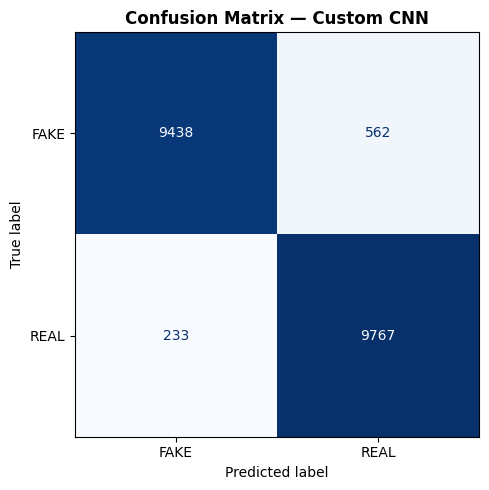

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

# run the model on every image in the test set
# predict returns probabilities between 0 and 1
predicted_probabilities = cnn_model.predict(test_dataset, verbose=1).flatten()

predicted_labels = (predicted_probabilities > 0.5).astype(int)


true_labels = np.array(test_labels)

# stats
print('--- Custom CNN — Test Set Evaluation ---')
print(classification_report(true_labels, predicted_labels, target_names=CLASS_NAMES))
print(f'Overall Accuracy : {accuracy_score(true_labels, predicted_labels):.4f}')
print(f'Overall F1 Score : {f1_score(true_labels, predicted_labels):.4f}')

# confusion matrix
confusion = confusion_matrix(true_labels, predicted_labels)
display = ConfusionMatrixDisplay(confusion, display_labels=CLASS_NAMES)
figure, ax = plt.subplots(figsize=(5, 5))
display.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Custom CNN', fontweight='bold')
plt.tight_layout()
plt.show()

## Model Evaluation results
The CNN achieved 96.03% accuracy and a macro F1 score of 0.96 accorss 20,000 unseen test images, with balanced performanced across both classes. The model correctly identified 94% of fake images, and 98% of real ones, meaning it does best on the REAL images, and slightly worse on the AI generated ones.

## Model

Last Conv2D layer: conv2d_5


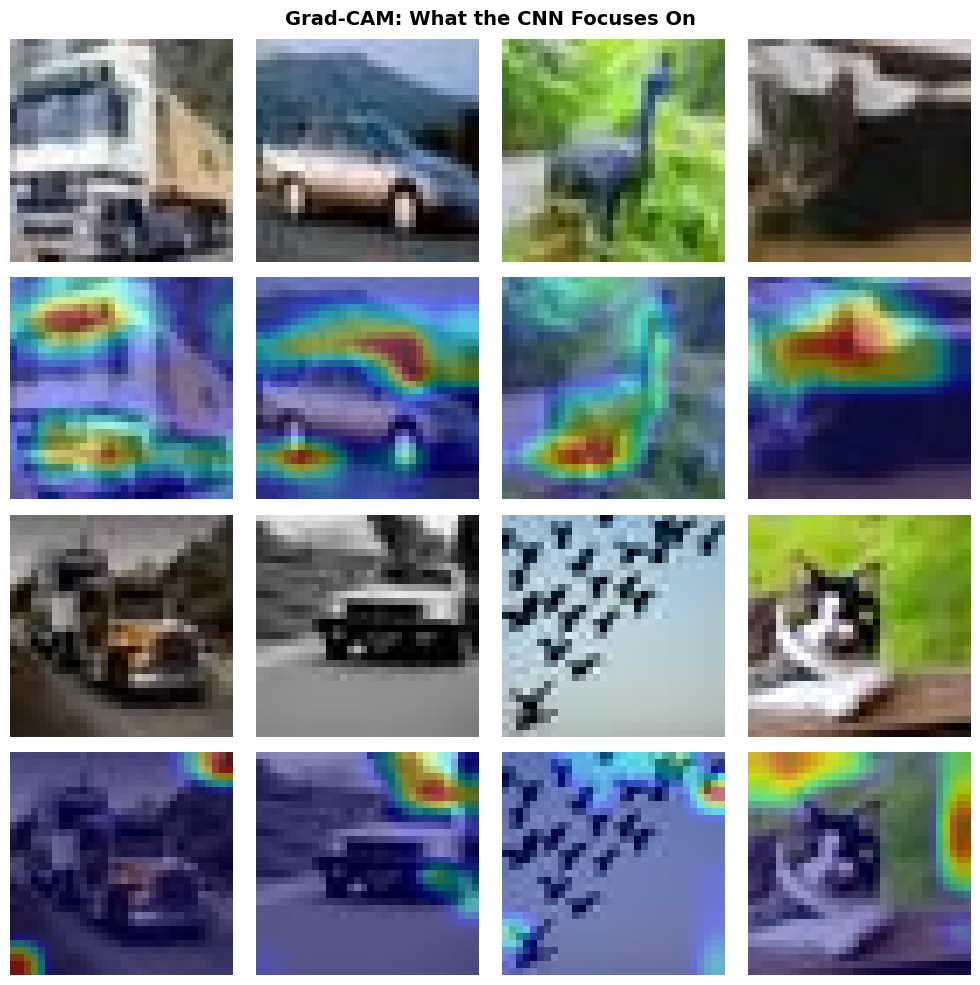

In [ ]:
# Grad-CAM implementation adapted from the official Keras documentation
# source: https://keras.io/examples/vision/grad_cam/
# Grad-CAM shows which parts of an image the model focused on when making its decision
# red regions in the heatmap = high attention, blue = low attention

import tensorflow as tf
def make_gradcam_heatmap(image_array, model, last_conv_layer_name):
    # create a sub-model that outputs both the last conv layer activations
    # and the final prediction
    with tf.GradientTape() as tape:
        x = image_array
        conv_output = None

        # manually pass through each layer so we can intercept
        # the last conv layer output
        for layer in model.layers:
            x = layer(x)
            if layer.name == last_conv_layer_name:
                conv_output = x
                tape.watch(conv_output)

        class_channel = x[:, 0]

    grads = tape.gradient(class_channel, conv_output)

    # pool gradients over spatial dimensions to get one weight per filter
    # this is the mean intensity of the gradient over each feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # weight each channel by how important it is, then sum to get the heatmap
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # relu removes negative values
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(original_image, heatmap, alpha=0.4):
    # resize heatmap to match original image dimensions
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))

    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # blend original image and heatmap using alpha weighting
    return cv2.addWeighted(original_image, 1 - alpha, heatmap_colored, alpha, 0)


# find the last Conv2D layer name automatically from the model
last_conv_layer = [layer.name for layer in cnn_model.layers if isinstance(layer, layers.Conv2D)][-1]
print(f'Last Conv2D layer: {last_conv_layer}')

number_to_show = 4
real_samples = real_images[:number_to_show]
fake_samples = fake_images[:number_to_show]

figure, axes = plt.subplots(4, number_to_show, figsize=(number_to_show * 2.5, 10))
row_labels = ['REAL (original)', 'REAL (Grad-CAM)', 'FAKE (original)', 'FAKE (Grad-CAM)']

for column in range(number_to_show):
    for row_group, images_sample in enumerate([real_samples, fake_samples]):
        image = images_sample[column]

        # normalize to 0-1 and add batch dimension before passing to model
        image_input = np.expand_dims(image.astype(np.float32) / 255.0, axis=0)

        heatmap = make_gradcam_heatmap(image_input, cnn_model, last_conv_layer)
        overlay = overlay_gradcam(image, heatmap)

        base_row = row_group * 2
        axes[base_row,     column].imshow(image);   axes[base_row,     column].axis('off')
        axes[base_row + 1, column].imshow(overlay); axes[base_row + 1, column].axis('off')

# label the rows on the left side
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=0, labelpad=80, va='center')

figure.suptitle('Grad-CAM: What the CNN Focuses On', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Report
## Q1 What is the project about? Or what problems you are going to solve?
This project addresses what I believe is the growing problem of AI-generated image detection. As models get better it becomes harder to distinguish between real and fake images. The goal of this project is to identify measurable differences between real and AI-generated images using image processing techniques, looking at edge density, color, noisiness, and the frequency domain. It also looks to deploy a machine learning model, in this case a convolutional neural network, to attempt to classify models as real or AI. The CIFAKE dataset was used, consisting of 120,000 images split between real and AI generated, where the real images were taking from CIFAR-10 (https://www.kaggle.com/c/cifar-10), and the AI images were generated with stable diffusion 10. All images are 32x32.




## Q3 Python Libraries and Packages Used

| Library | Version | Purpose |
|---|---|---|
| `tensorflow` | 2.21.0 | Model building, training, and tf.data pipeline |
| `keras` | (included with tensorflow) | CNN layers, callbacks, optimizers |
| `opencv-python` (`cv2`) | 4.x | Image loading, grayscale conversion, edge detection, FFT, filtering |
| `numpy` | 1.x | Numerical computation, array operations, FFT |
| `matplotlib` | 3.x | All visualizations and plots |
| `scikit-learn` | 1.x | Confusion matrix, classification report, F1 and accuracy metrics |
| `tqdm` | 4.x | Progress bars during image loading |
| `pathlib` | (built-in) | File path handling for dataset directories |
| `random` | (built-in) | Shuffling image paths for dataset splitting |
| `os` | (built-in) | File system operations for Kaggle setup |

Claude helped with this! I just shared all the imports.

## Q4: Image Processing and Computer Vision Algorithms
My approach for this project wasn't super structured, I instead wanted to explore as many things a possible to see what stuck. I applied several techniques to the dataset to see which revealed a measurable difference between AI-generated images and Real ones, then used the findings to movitate my machine learning model.

**Fast Fourier Transform**
Converts images from the spatial domain (pixel brightness values x,y position) to the frequency domain (how much of each frequencuy is present in the image), all us to see how brightness changes across an image at different scales. I chose this algorithm not so much because I fully understood it, but rather to understand myself. I more wanted to visualize what it was doing, and see if it showed any differences in the two classes.

**Canny Edge**
I chose this one because I wanted to see if there was a difference in the percentage of edges in the two classes. The edge density of an image is super helpful, it shows really any sharp contrasts and lines, and whether AI-generated images would produce more, less, or the same amount. It first converts the image to grayscale, smooths with a Gaussian filter, then computes the gradient magnitudes at every pixel. It finally thresholds the pixels. Edge density was then calculated as a fraction of pixels marked as edges.

**Color profiles**
For each image, the pixel intesity value in each RGB channel are binned into 64 buckets from 0 to 255. This gives us a histogram showing how many pixels in that channel fall into each brightness range. Averaging these histograms then across the 60,000 images per class gives us the full picture. I chose this to see if there was any color differences that AI generated. Maybe it overused some colors and underused others?

**Local Standard Deviation (how rough the image is/noise)**
A 3x3 averaging kernel is convolved across the grayscale images use cv2.filter2D to compute the local mean at every pixel position. The same kernel is applied to the squared values to compute the local mean of squares. The variance formula (thank you statistics) E[X^2] - E[X]^2 is then applied at every pixel to get the local variance, which is squared rooted to give the local standard devation. Averaging all of these across the 60,000 images, with each image getting a 'noiseness' score per image, gave the graphs. I chose this for the same reasons as before, do AI-generated images leave behind more noise? Less?

These four techniques were chosen together because they each measure different dimesions of image structure, frequency, edges, color, and pixel textures, giving me what I believe is a comprehensive overview of the differences between the classes.

## Q5 Discussion and Analysis
The project successfully demonstrated that AI-generated images (in the case of my dataset) are distinguishable from real photographs using image processing techniques and deep learning.

The image processing techniques revealed four consistent differences between the classes. FFT analysis show AI images carry more high-frequency energy, edge detection show real images on average a higher percentage of edge density, the color histograms revealed a blue color bias in AI images at lower values, and noise analysis revealed that AI images are slightly noiser at the pixel level despite appearing to be smoother. None of these on their own could be shown to distinctly classify an image reliably, but together they gave a consistent picture of of diffusion-generated images differ from real photographs at the lowest level.

The CNN classifier built on these findings by learning to combine mulitple signals automatically from data, with 96.03% accuracy and a macro F1 score of 0.96 on the 20,000 test images. The balanced precision between both classes suggests that the model learned generalizable features rather than overfitting to undetectable patterns. The Grad-Cam confirmed this, the model focused on edges, backgrounds, and textural regions rather than showing the subject of the image, which I believe is consistent with the image processing techniques I used which found distinquishable differences.

The combonation of typical analyiss and deep learning was the backbone of this project. The image processing techniques provided readable insight into what makes AI images detectable, while the CNN provided the classification performance needed for unseen data.

## Q6: Future Work

I want to adapt the model to take any resolution image, as CIFAKE is only 32x32, and I haven't testing normalizing images to this size, but I predict it wouldn't go well. I'd like to try more image processing stuff as well, like feature extraction and morphological processing. Also to port it over to a website that can take any image and give a rating for AI or not.

##Q7: Additional Notes for Grading
Run from top to bottom, and if you have no GPU credits, in the data loading cell adjust max_per_class=60000 to max_per_class=500. Also adjust max_per_class=5000 in the data pipeline cell. And finally adjust the # of epochs from 20 -> 3 or 4. Thank you for a great class professor!

## Q2 Which part is your own work/idea, which part is an implementation of other people’s idea, or use of AI, which part is using some existing code/examples?

**Data Download & Setup**

The Kaggle API authentication and dataset download approach was implemented by me. Claude did help here with a small bug I had, with the KAGGLE api not working. These were both useful for progress bars and finding jpegs in the files. https://tqdm.github.io/  https://docs.python.org/3/library/pathlib.html#pathlib.Path.glob


**Data Loading & Exploration**

The data loading pipeline and class distribution plot were written by me using OpenCV and matplotlib. Claude helped with a bug on the dataloading, but the rest I knew from previous machine learning projects. For def load_images_from_split, Claude helped format the images, they looked really bad loading one by one.

**FFT Frequency Analysis**

The FFT frequency analysis cell, including the radial frequency profile and low/high pass filtering demonstration, was developed with significant assistance from Claude (AI). The underlying concepts,  Fourier Transform, spatial vs. frequency domain were applied/covered in lectures and resources from class. The application of np.fft.fft2, np.fft.fftshift, and the circular mask construction for filtering were implemented with AI assistance.
numpy FFT documentation: https://numpy.org/doc/stable/reference/routines.fft.html

**Edge Density Analysis**

The Canny edge detection analysis and histogram/box plot visualization were written by me. Canny edge detection was covered in class. The edge density metric, computing the fraction of edge pixels per image, is my own approach to quantifying the difference between classes, with some help from Claude with the formatting.


**Color Histogram Analysis**

The per-channel color histogram comparison was written by me using numpy and matplotlib. The approach of comparing average histograms across classes is my own analytical choice.


**Noise/Texture Analysis**

The local standard deviation texture analysis was written by me. The use of cv2.filter2D with an averaging kernel to compute local mean and variance follows the variance formula E[X²] - E[X]² from statistics and image filtering, but Claude did help get it working.


**Data Pipeline (tf.data)**

The tf.data pipeline replacing ImageDataGenerator was implemented by me with reference to TensorFlow documentation. The augmentation choices (horizontal flip, brightness) are my own decisions based on the dataset characteristics.
https://www.tensorflow.org/guide/data

**CNN Architecture**

The custom CNN architecture was designed by me. The three-block structure with increasing filter counts, BatchNormalization, MaxPooling, and Dropout follows standard CNN design principles I researched through TensorFlow/Keras documentation and class material.
https://www.tensorflow.org/guide/keras


**Training**

The training loop, callback configuration (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint), and hyperparameter choices were implemented by me. The ReduceLROnPlateau patience setting was adjusted based on my own analysis of the training logs.
https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ReduceLROnPlateau

**Evaluation**

The model evaluation cell including classification report, confusion matrix, and accuracy/F1 metrics was implemented with assistance from Claude (AI). The interpretation and analysis of the results, including the asymmetric precision/recall finding, is my own.
scikit-learn metrics documentation: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics

**Feature Map Visualization**

The feature map extraction and visualization using a sub-model was implemented by me with reference to Keras documentation on model layer outputs.


**Grad-CAM**

The Grad-CAM implementation using GradientTape was assisted by Claude (AI) due to a Keras 3 compatibility issue with the standard approach. The fix using manual layer traversal instead of building a new Model was debugged with AI assistance.

Keras Grad-CAM example: https://keras.io/examples/vision/grad_cam/

